In [1]:
import os
import shutil

source = r"C:\Users\Admin\PyCharmMiscProject\E-Commerce-data-pipeline\data\cleaned_sales.csv"
destination = r"C:\Users\Admin\PyCharmMiscProject\ecommerce-sales-eda\data\cleaned_sales.csv"

# Automatically creates the 'data' directory if missing
os.makedirs(os.path.dirname(destination), exist_ok=True)

# Copy file
shutil.copy(source, destination)
print("File copied successfully!")

File copied successfully!


## import libraries

In [15]:
import pandas as pd
import seaborn as sns

### Total revenue for Each category

In [10]:
df = pd.read_csv("data/cleaned_sales.csv")
category_summary = (
    df.groupby("category")["sales"]
    .sum()
    .reset_index()
    .sort_values(by="sales", ascending=False)
)

total_revenue = category_summary["sales"].sum()
category_summary["share_%"] = (category_summary["sales"] / total_revenue) * 100

styled_table = (
    category_summary.style.format({"sales": "${:,.2f}", "share_%": "{:.1f}%"})
     .hide(axis="index")
    .set_caption("Category Revenue Performance Breakdown")
)

display(styled_table)

category,sales,share_%
Grocery,"$125,421.98",18.8%
Clothing,"$109,679.13",16.4%
Electronics,"$103,122.96",15.4%
Home,"$87,936.29",13.1%
Not Known,"$85,577.59",12.8%
Toys,"$84,434.50",12.6%
Beauty,"$72,616.27",10.9%


### bar plot showing the results of the table above

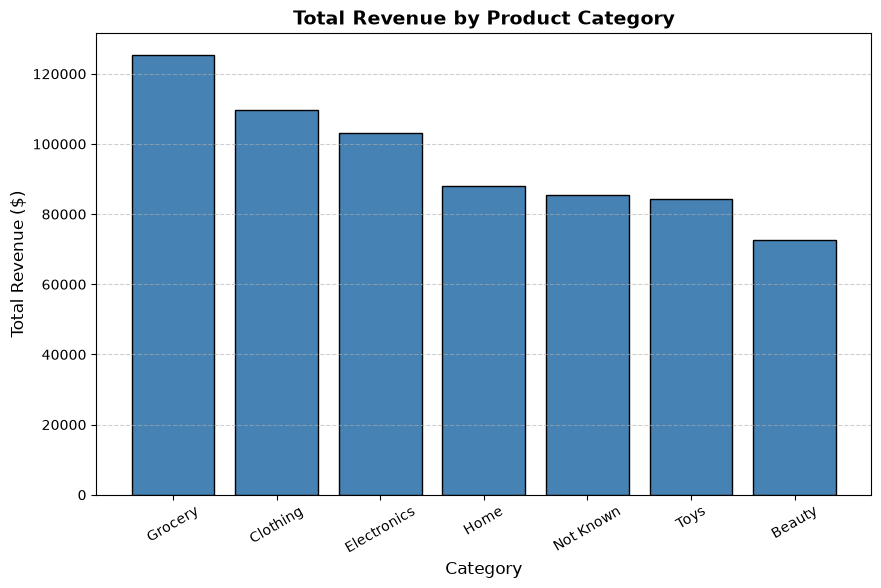

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(
    category_summary["category"],
    category_summary["sales"],
    color="steelblue",
    edgecolor="black",
)

plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

plt.xticks(rotation=30)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig("reports/category_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

### monthly revenue line graph

Peak Month: August ($216,079.40)


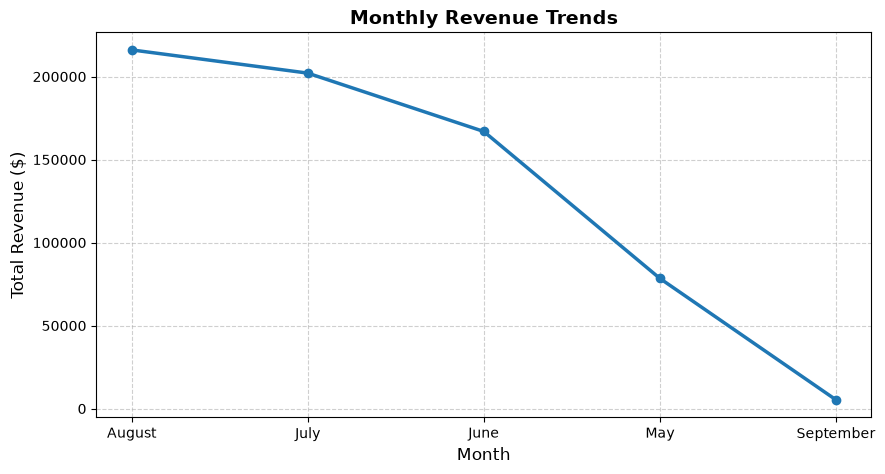

In [12]:
monthly_revenue = (
    df.groupby("month")["sales"]
    .sum()
    .reset_index()
)

peak_month = monthly_revenue.sort_values(by="sales", ascending=False).iloc[0]
print(f"Peak Month: {peak_month['month']} (${peak_month['sales']:,.2f})")

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["sales"],
    marker="o",         
    color="#1f77b4",     
    linewidth=2.5,      
    linestyle="-"
)
# Add titles and axis labels
plt.title("Monthly Revenue Trends", fontsize=14, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)

# Add gridlines for readability across values
plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("reports/monthly_trends.png", dpi=300, bbox_inches="tight")

# 8. Display inline plot
plt.show()

### Which gender buys the most

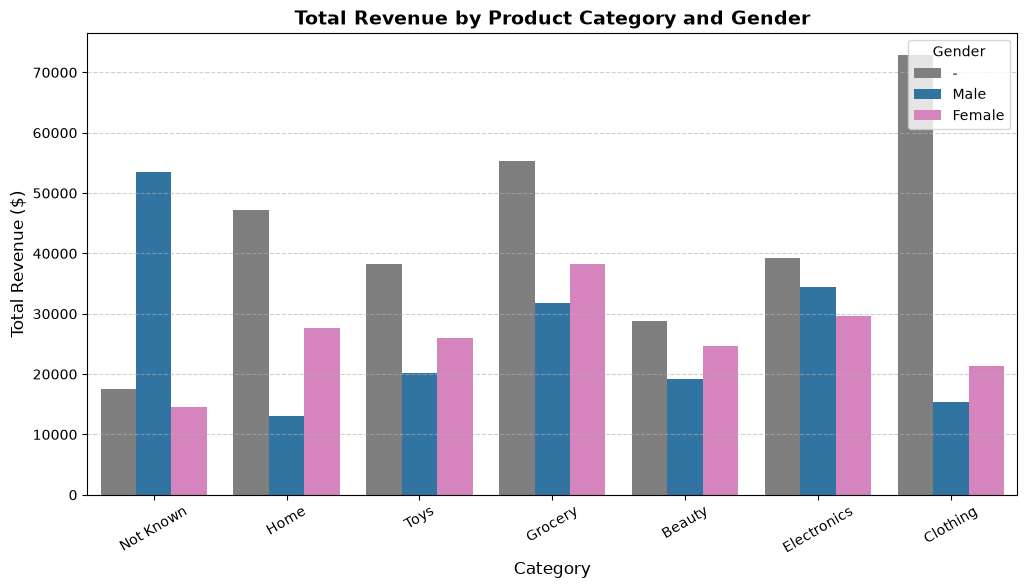

In [17]:
gender_colors = {
    "Male": "#1f77b4", "M": "#1f77b4",
    "Female": "#e377c2", "F": "#e377c2",
    "-": "#7f7f7f", "Unknown": "#7f7f7f"
}

plt.figure(figsize=(12, 6))

# Render grouped bar chart
ax = sns.barplot(
    data=df,
    x="category",
    y="sales",
    hue="gender",
    estimator=sum,
    errorbar=None,
    palette=gender_colors
)

plt.title("Total Revenue by Product Category and Gender", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.xticks(rotation=30)
plt.legend(title="Gender", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig("reports/gender_revenue_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

## Find the top 10 customers by spending

In [20]:
top_10_customers = (
    df.groupby(["customer_name", "email", "phone_number"])
    .agg(
        total_spend=("sales", "sum"),
        total_orders=("order_id", "count"),
        avg_order_value=("sales", "mean")
    )
    .reset_index()
    .sort_values(by="total_spend", ascending=False)
    .head(10)
)

styled_top_10 = (
    top_10_customers.style.format({
        "total_spend": "${:,.2f}",
        "avg_order_value": "${:,.2f}"
    })
     .hide(axis="index")
    .set_caption("Top 10 Customers by Total Spend")
)

display(styled_top_10)

customer_name,email,phone_number,total_spend,total_orders,avg_order_value
Terence Andriamahery,terence.andriamahery36@icloud.com,(310) 637-4373,"$39,376.00",1,"$39,376.00"
Rani Thomas,Invalid email,(412) 470-9590,"$29,009.00",1,"$29,009.00"
Maj Dixon,maj.dixon18@gmail.com,Unknown,"$24,502.00",1,"$24,502.00"
Agns Keita,agnès.keita42@gmail.com,(704) 464-9762,"$4,855.40",1,"$4,855.40"
Chiawei Njai,chia-wei.njai97@gmail.com,(903) 927-5104,"$4,755.00",1,"$4,755.00"
Hortnsia Kralj,horténsia.kralj11@outlook.com,(407) 877-7412,"$4,584.50",1,"$4,584.50"
Namiq Silva,namiq.silva84@icloud.com,(616) 968-0928,"$4,483.50",1,"$4,483.50"
Hendrik Fettah,hendrik.fettah36@yahoo.com,(602) 433-9860,"$4,455.45",1,"$4,455.45"
Angela Dangelo,Invalid email,Unknown,"$4,445.64",1,"$4,445.64"
Yaya Cordova,yaya.cordova57@gmail.com,(518) 233-3072,"$4,355.30",1,"$4,355.30"


### top rated departments vs low rated departments

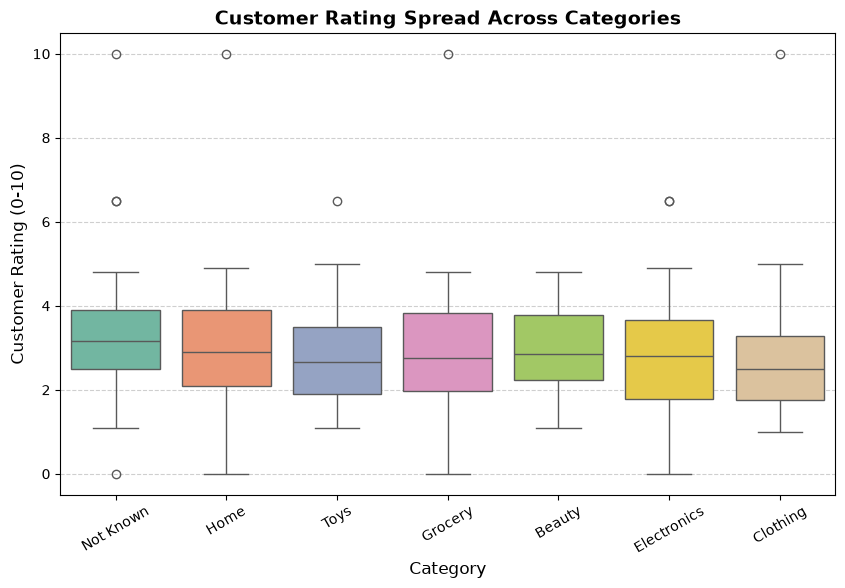

In [22]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="category",
    y="customer_rating",
    hue = "category",
    legend = False,
    palette="Set2"
)

plt.title("Customer Rating Spread Across Categories", fontsize=14, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Customer Rating (0-10)", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig("reports/category_rating_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### correlation between price point and customer rating

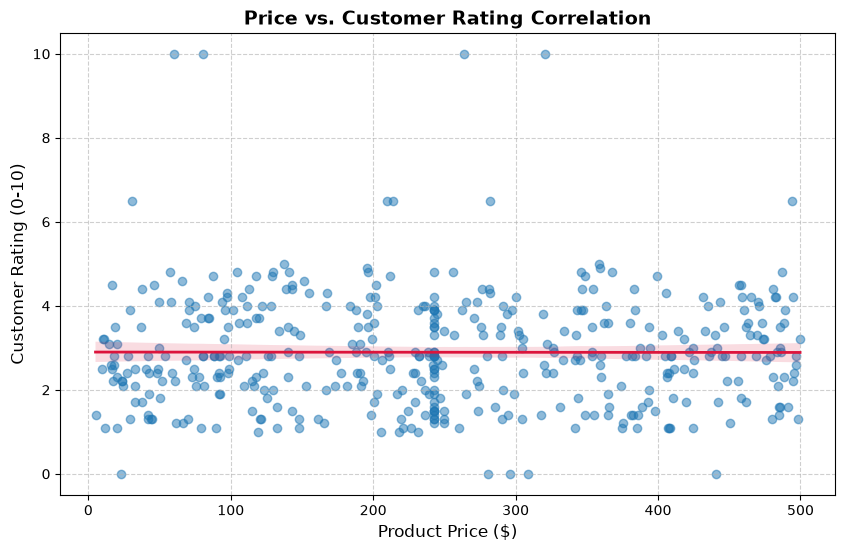

In [25]:
plt.figure(figsize=(10, 6))


sns.regplot(
    data=df,
    x="price",
    y="customer_rating",
    scatter_kws={"alpha": 0.5, "color": "#1f77b4"},  
    line_kws={"color": "crimson", "linewidth": 2} 
)


plt.title("Price vs. Customer Rating Correlation", fontsize=14, fontweight="bold")
plt.xlabel("Product Price ($)", fontsize=12)
plt.ylabel("Customer Rating (0-10)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.savefig("reports/price_vs_rating_scatterplot.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Returns a value between -1.0 and +1.0
df["price"].corr(df["customer_rating"])

np.float64(-0.0019197221642673528)

### Product price shows zero linear correlation with customer ratings.